In [1]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam, Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

import time

c:\Users\juliu\anaconda3\envs\GEGE\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set random seed for reproducibility
pyro.set_rng_seed(42)

In [3]:
# load the data
test_data_path = "small_test_data.csv"
test_label_path = "small_test_labels.csv"
test_data = pd.read_csv(test_data_path).values.astype(np.float32)
test_label = pd.read_csv(test_label_path).values

val_data_path = "small_val_data.csv"
val_label_path = "small_val_labels.csv"
val_data = pd.read_csv(val_data_path).values.astype(np.float32)
val_label = pd.read_csv(val_label_path).values

print("test_data shape:", test_data.shape)
print("test_label shape:", test_label.shape)

print(test_data[0,0:10])

test_data shape: (200, 400)
test_label shape: (200, 1)
[5.53000e-02 0.00000e+00 5.55492e+01 4.71580e+00 3.67360e+00 2.70879e+01
 1.88500e-01 1.50104e+01 1.45420e+01 1.54886e+01]


In [4]:
print(f"AML", np.sum(test_label == 0))
print(f"ALL", np.sum(test_label == 1))
print(f"Normal", np.sum(test_label == 2))

AML 118
ALL 67
Normal 15


In [5]:
def normalize_data(data):
    # Z-score normalization per gene
    X_train_mean = data.mean(axis=0)
    X_train_std = data.std(axis=0) + 1e-6  # avoid div-by-zero
    X_norm = (data - X_train_mean) / X_train_std
    X_clipped = np.clip(X_norm, -15, 15)
    return X_clipped, X_train_mean, X_train_std

X_norm, X_train_mean, X_train_std = normalize_data(test_data)

In [6]:
def supervised_ppca_model_ard(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape

    # 1) ARD prior on α
    a0 = torch.tensor(1e-3)
    b0 = torch.tensor(1e-3)
    alpha = pyro.sample(
        "alpha",
        dist.Gamma(a0.expand(latent_dim),
                   b0.expand(latent_dim))
            .to_event(1)
    )

    # 2) ARD prior on W (no plates, event_dim=2)
    W = pyro.sample(
        "W",
        dist.Normal(
            torch.zeros(latent_dim, n_genes),
            alpha.unsqueeze(-1).rsqrt()
                 .expand(latent_dim, n_genes)
        ).to_event(2)
    )

    # 3) Bayesian softmax head priors
    A = pyro.sample(
        "A",
        dist.Normal(0., 1.)
            .expand([n_classes, latent_dim])
            .to_event(2)
    )
    b = pyro.sample(
        "b",
        dist.Normal(0., 1.)
            .expand([n_classes])
            .to_event(1)
    )

    # 4) Per-gene noise σ
    sigma = pyro.param("sigma_loc",
                       torch.full((n_genes,), 0.1),
                       constraint=dist.constraints.positive)

    # 5) Data plate
    with pyro.plate("data", n_samples):
        # latent codes z | α
        z = pyro.sample(
            "z",
            dist.Normal(0., alpha.rsqrt()).to_event(1)
        )

        # reconstruction
        x_loc = z @ W
        pyro.sample("obs",
                    dist.Normal(x_loc, sigma).to_event(1),
                    obs=X)

        # classification
        logits = z @ A.T + b
        pyro.sample("y",
                    dist.Categorical(logits=logits),
                    obs=y)


def supervised_ppca_guide_ard(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape

    # 1) Variational posterior over α
    alpha_a = pyro.param("alpha_a",
                         torch.ones(latent_dim),
                         constraint=dist.constraints.positive)
    alpha_b = pyro.param("alpha_b",
                         torch.ones(latent_dim),
                         constraint=dist.constraints.positive)
    alpha = pyro.sample(
        "alpha",
        dist.Gamma(alpha_a, alpha_b).to_event(1)
    )

    # 2) Variational posterior q(W)
    w_loc   = pyro.param("w_loc",
                         torch.randn(latent_dim, n_genes))
    w_scale = pyro.param("w_scale",
                         torch.ones(latent_dim, n_genes),
                         constraint=dist.constraints.positive)
    pyro.sample(
        "W",
        dist.Normal(
            w_loc,
            (w_scale / alpha.unsqueeze(-1).sqrt())
               .expand(latent_dim, n_genes)
        ).to_event(2)
    )

    # 3) Variational posterior q(A), q(b)
    A_loc   = pyro.param("A_loc",
                         torch.randn(n_classes, latent_dim))
    A_scale = pyro.param("A_scale",
                         torch.ones(n_classes, latent_dim),
                         constraint=dist.constraints.positive)
    pyro.sample(
        "A",
        dist.Normal(A_loc, A_scale).to_event(2)
    )

    b_loc   = pyro.param("b_loc",
                         torch.zeros(n_classes))
    b_scale = pyro.param("b_scale",
                         torch.ones(n_classes),
                         constraint=dist.constraints.positive)
    pyro.sample(
        "b",
        dist.Normal(b_loc, b_scale).to_event(1)
    )

    # 4) Variational posterior q(z)
    z_loc   = pyro.param("z_loc",
                         torch.randn(n_samples, latent_dim))
    z_scale = pyro.param("z_scale",
                         torch.ones(n_samples, latent_dim),
                         constraint=dist.constraints.positive)
    with pyro.plate("data", n_samples):
        pyro.sample(
            "z",
            dist.Normal(z_loc,
                        z_scale / alpha.sqrt()).to_event(1)
        )


In [7]:
X_train_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_train_tensor = torch.tensor(test_label, dtype=torch.long).flatten()
latent_dim = 100
n_classes = 3

In [8]:
pyro.clear_param_store()
optimizer = ClippedAdam({"lr": 0.01})
svi = SVI(supervised_ppca_model_ard, supervised_ppca_guide_ard, optimizer, loss=Trace_ELBO())

start_time = time.time()

n_steps = 3000
for step in range(n_steps):
    loss = svi.step(X_train_tensor, y_train_tensor, latent_dim, n_classes)
    if step % 200 == 0:
        print(f"[Step {step}] Loss: {loss:.2f}")

# Total time spent
print(f"Total time spent: {time.time() - start_time:.2f} seconds")
print(f"Total time spent: {((time.time() - start_time) / 60):.2f} minutes")

[Step 0] Loss: 61919107315.81
[Step 200] Loss: 214898.60
[Step 400] Loss: 113395.50
[Step 600] Loss: 108359.43
[Step 800] Loss: 105745.79
[Step 1000] Loss: 98441.40
[Step 1200] Loss: 93836.16
[Step 1400] Loss: 93874.69
[Step 1600] Loss: 92130.39
[Step 1800] Loss: 93940.58
[Step 2000] Loss: 90740.81
[Step 2200] Loss: 92688.67
[Step 2400] Loss: 91476.87
[Step 2600] Loss: 89980.85
[Step 2800] Loss: 92068.30
Total time spent: 46.44 seconds
Total time spent: 0.77 minutes


In [9]:
print(list(pyro.get_param_store().keys()))

['alpha_a', 'alpha_b', 'w_loc', 'w_scale', 'A_loc', 'A_scale', 'b_loc', 'b_scale', 'z_loc', 'z_scale', 'sigma_loc']


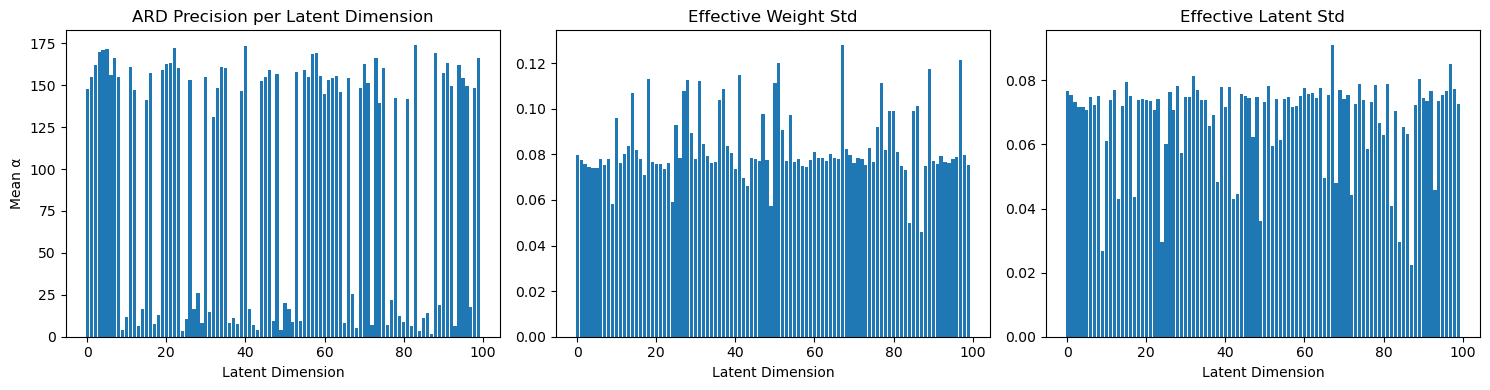

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1) ARD precision means
alpha_a = pyro.param("alpha_a").detach().cpu().numpy()
alpha_b = pyro.param("alpha_b").detach().cpu().numpy()
alpha_mean = alpha_a / alpha_b
latent_dim = alpha_mean.shape[0]

# 2) Effective W std (avg over genes)
w_scale = pyro.param("w_scale").detach().cpu().numpy()
w_eff_mean = (w_scale / np.sqrt(alpha_mean[:, None])).mean(axis=1)

# 3) Effective z std (avg over samples)
z_scale = pyro.param("z_scale").detach().cpu().numpy()
z_eff_mean = (z_scale / np.sqrt(alpha_mean)).mean(axis=0)

# Plot everything in one figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(np.arange(latent_dim), alpha_mean)
axes[0].set(title="ARD Precision per Latent Dimension",
            xlabel="Latent Dimension", ylabel="Mean α")

axes[1].bar(np.arange(latent_dim), w_eff_mean)
axes[1].set(title="Effective Weight Std", xlabel="Latent Dimension")

axes[2].bar(np.arange(latent_dim), z_eff_mean)
axes[2].set(title="Effective Latent Std", xlabel="Latent Dimension")

plt.tight_layout()
plt.show()


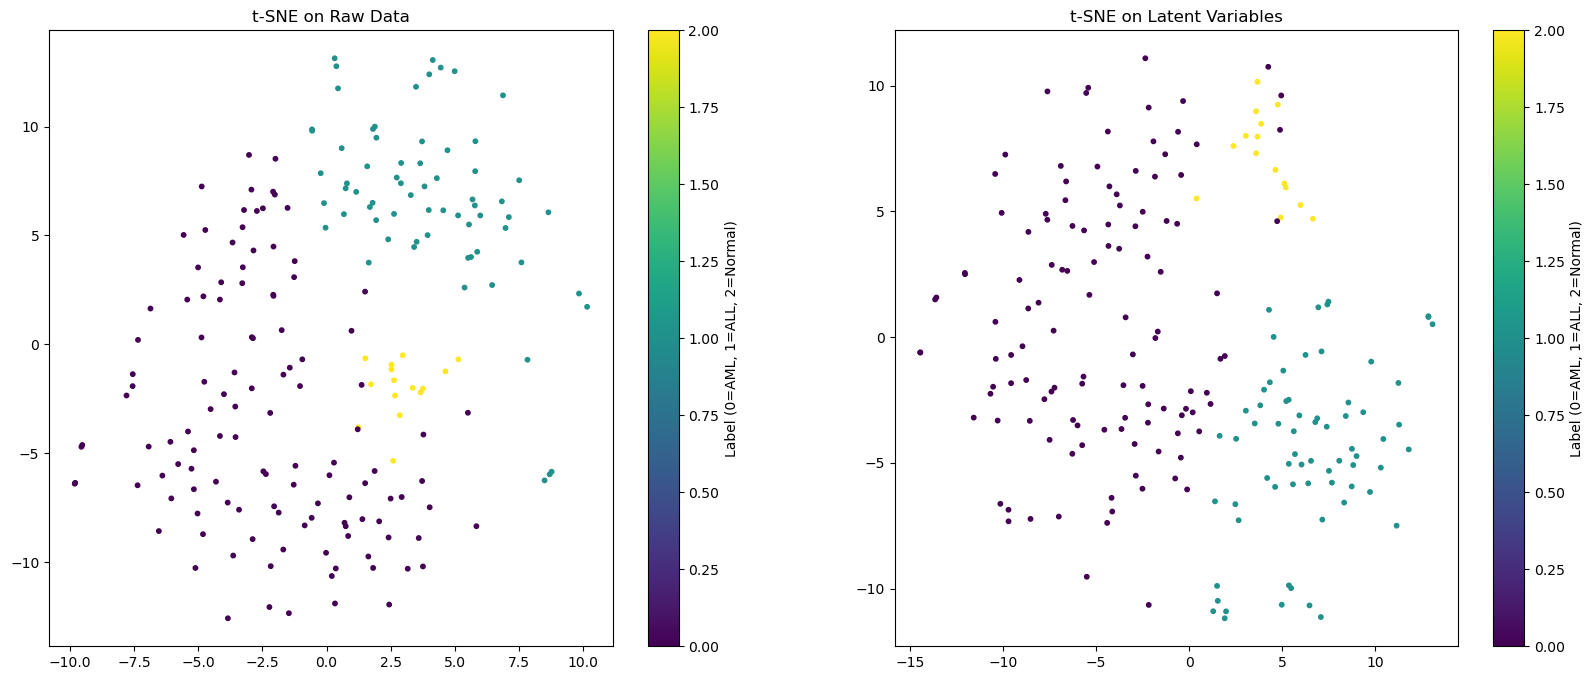

In [11]:
from sklearn.manifold import TSNE

def TSNE_plots(z_loc, labels):
    raw_data_tsne = TSNE(n_components=2).fit_transform(X_norm)
    z_post_tsne = TSNE(n_components=2).fit_transform(z_loc.detach().cpu().numpy())

    plt.figure(figsize=(20, 8))
    plt.subplot(1, 2, 1)
    plt.scatter(raw_data_tsne[:, 0], raw_data_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Raw Data")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.subplot(1, 2, 2)
    plt.scatter(z_post_tsne[:, 0], z_post_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Latent Variables")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.show()

z_loc = pyro.param("z_loc").detach()
TSNE_plots(z_loc, test_label)


In [12]:
#normalization for validation data
X_val_norm, _, _ = normalize_data(val_data)
X_val_tensor = torch.tensor(X_val_norm, dtype=torch.float32)

In [13]:
# 0) Prepare your validation tensors
# — use the *training* mean/std, not val‐data’s own, for consistency
X_val_norm = (val_data - X_train_mean) / X_train_std
X_val_norm = np.clip(X_val_norm, -5, 5)
X_val_tensor = torch.tensor(X_val_norm, dtype=torch.float32)
y_val_tensor = torch.tensor(val_label, dtype=torch.long).flatten()

import torch
import pyro
import pyro.distributions as dist
import pyro.poutine as poutine
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam

# 1) Grab the posterior‐mean values from the param store
ps       = pyro.get_param_store()
alpha_pm = (ps["alpha_a"] / ps["alpha_b"]).detach()  # [latent_dim]
W_pm     = ps["w_loc"].detach()                      # [latent_dim, n_genes]
A_pm     = ps["A_loc"].detach()                      # [n_classes, latent_dim]
b_pm     = ps["b_loc"].detach()                      # [n_classes]
# note: sigma_loc remains a pyro.param inside the model

# 2) Build a conditioned version of your trained model
fixed = {
    "alpha": alpha_pm,
    "W":     W_pm,
    "A":     A_pm,
    "b":     b_pm
}
cond_model = poutine.condition(supervised_ppca_model_ard, data=fixed)

# 3) A guide that only defines z_loc_val, z_scale_val,
#    and uses the learned ARD precision α to scale the latent prior
def infer_z_val_guide(X, y, latent_dim, n_classes):
    n_val = X.shape[0]

    # new variational parameters for the validation latents
    z_loc_val   = pyro.param(
        "z_loc_val",
        torch.randn(n_val, latent_dim)
    )
    z_scale_val = pyro.param(
        "z_scale_val",
        torch.ones(n_val, latent_dim),
        constraint=dist.constraints.positive
    )

    # plug in the trained ARD precisions
    ps       = pyro.get_param_store()
    alpha_pm = (ps["alpha_a"] / ps["alpha_b"]).detach()

    with pyro.plate("data", n_val):
        pyro.sample(
            "z",
            dist.Normal(
                z_loc_val,
                z_scale_val / alpha_pm.sqrt()
            ).to_event(1)
        )

# 4) Freeze the leaf parameter for sigma_loc so it stays fixed
ps._params["sigma_loc"].requires_grad_(False)

# 5) Run SVI to infer only z_loc_val / z_scale_val
optimizer = Adam({"lr": 1e-2})
svi_inf   = SVI(
    cond_model,
    infer_z_val_guide,
    optimizer,
    loss=Trace_ELBO()
)

n_steps = 3000
for step in range(n_steps):
    loss = svi_inf.step(
        X_val_tensor,
        y_val_tensor,
        latent_dim,
        n_classes
    )
    if step % 100 == 0:
        print(f"[val step {step}] loss = {loss:.1f}")

# 6) Pull out your inferred validation latents
z_post_loc   = pyro.param("z_loc_val").detach()
z_post_scale = pyro.param("z_scale_val").detach()



[val step 0] loss = 2314918.1
[val step 100] loss = 569879.9
[val step 200] loss = 199670.5
[val step 300] loss = 101271.7
[val step 400] loss = 72178.6
[val step 500] loss = 61695.9
[val step 600] loss = 54778.6
[val step 700] loss = 52926.0
[val step 800] loss = 51679.1
[val step 900] loss = 48873.3
[val step 1000] loss = 48331.4
[val step 1100] loss = 47536.1
[val step 1200] loss = 47022.6
[val step 1300] loss = 46072.9
[val step 1400] loss = 46463.9
[val step 1500] loss = 45471.1
[val step 1600] loss = 45445.0
[val step 1700] loss = 45027.6
[val step 1800] loss = 44878.7
[val step 1900] loss = 44547.7
[val step 2000] loss = 44812.8
[val step 2100] loss = 44355.2
[val step 2200] loss = 44378.9
[val step 2300] loss = 44159.7
[val step 2400] loss = 44184.3
[val step 2500] loss = 44070.0
[val step 2600] loss = 44115.2
[val step 2700] loss = 44078.2
[val step 2800] loss = 44108.8
[val step 2900] loss = 43953.2


In [14]:
import torch

# 1) Grab your frozen classifier parameters
A_loc = pyro.param("A_loc").detach()  # [n_classes, latent_dim]
b_loc = pyro.param("b_loc").detach()  # [n_classes]

# 2) Compute logits and predictions
#    z_post_loc is [n_val, latent_dim]; A_loc.T is [latent_dim, n_classes]
logits = z_post_loc @ A_loc.T + b_loc  # shape [n_val, n_classes]
preds  = torch.argmax(logits, dim=1)   # shape [n_val]

# 3) Compare to the true labels
correct = (preds == y_val_tensor).sum().item()
total   = y_val_tensor.size(0)
acc     = correct / total * 100.0

print(f"Validation: {correct}/{total} correct → {acc:.2f}% accuracy")

Validation: 189/200 correct → 94.50% accuracy


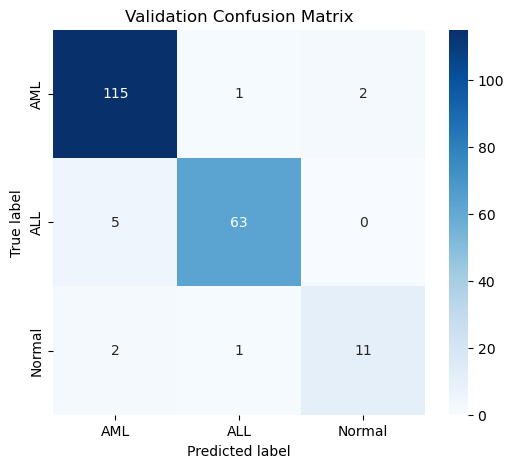

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1) Make predictions as before
A_loc = pyro.param("A_loc").detach()      # [n_classes, latent_dim]
b_loc = pyro.param("b_loc").detach()      # [n_classes]
logits = z_post_loc @ A_loc.T + b_loc     # [n_val, n_classes]
preds  = torch.argmax(logits, dim=1).cpu().numpy()
truth  = y_val_tensor.cpu().numpy()

# 2) Compute confusion matrix
cm = confusion_matrix(truth, preds, labels=[0,1,2])

# 3) Plot it
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["AML","ALL","Normal"],
            yticklabels=["AML","ALL","Normal"],
            cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()


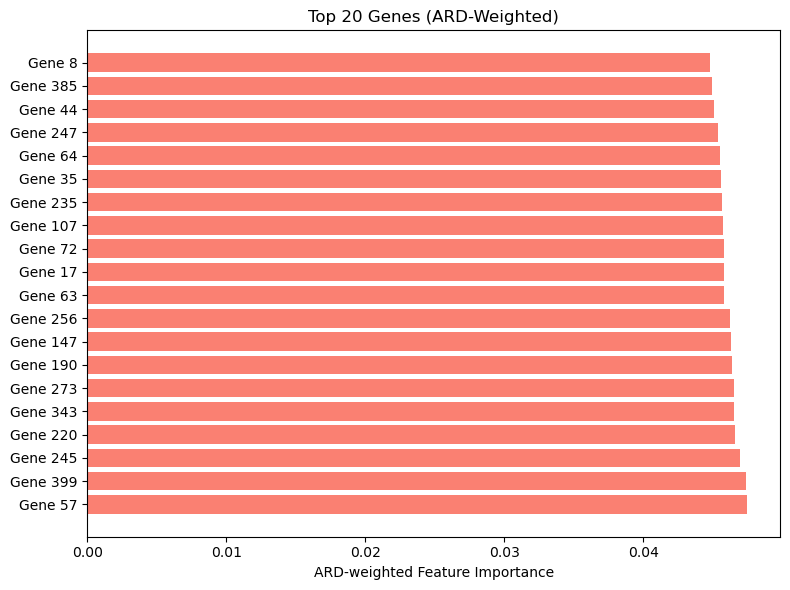

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def compute_feature_importance_ard(W_post, alpha_a, alpha_b, top_n=20):
    """
    Compute feature importance by first scaling each latent-dimension
    of W_post by 1/sqrt(alpha_mean), then taking the mean abs weight.
    
    W_post:   np.array of shape [latent_dim, n_genes]
    alpha_a:  np.array shape [latent_dim]
    alpha_b:  np.array shape [latent_dim]
    """
    # posterior mean of ARD precisions
    alpha_mean = alpha_a / alpha_b                   # [latent_dim]
    # effective scaling per latent dimension
    scale = 1.0 / np.sqrt(alpha_mean)                # [latent_dim]
    # apply scale to each row of W_post
    W_weighted = W_post * scale[:, None]             # [latent_dim, n_genes]
    
    # now compute feature importance
    feature_importance = np.abs(W_weighted).mean(axis=0)  # [n_genes]
    # pick top_n
    top_idx = np.argsort(feature_importance)[-top_n:]
    top_imp = feature_importance[top_idx]
    return top_idx, top_imp

def plot_top_genes_ard(top_indices, top_importance, top_n=20, gene_names=None):
    if gene_names is None:
        labels = [f"Gene {i}" for i in top_indices]
    else:
        labels = [gene_names[i] for i in top_indices]
    plt.figure(figsize=(8, max(4, top_n*0.3)))
    plt.barh(labels, top_importance, color="salmon")
    plt.xlabel("ARD-weighted Feature Importance")
    plt.title(f"Top {top_n} Genes (ARD-Weighted)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# pull W_loc and alpha params from Pyro
ps       = pyro.get_param_store()
W_post   = ps["w_loc"].detach().cpu().numpy()      # [latent_dim, n_genes]
alpha_a  = ps["alpha_a"].detach().cpu().numpy()    # [latent_dim]
alpha_b  = ps["alpha_b"].detach().cpu().numpy()    # [latent_dim]

top_n = 20
top_idx, top_imp = compute_feature_importance_ard(W_post, alpha_a, alpha_b, top_n=top_n)
plot_top_genes_ard(top_idx, top_imp, top_n=top_n, gene_names=None)
